# 🎓 Career Satisfaction 5-Class Supervised Classification & ML Benchmarking (KUET Cohort)
### Project: Graduate Career & Industry Feedback Survey Analysis — Khulna University of Engineering & Technology (KUET)
**Dataset:** `dataset.xlsx` ($N = 58$ raw KUET responses, 26 survey columns)  
**Task:** Supervised Multi-Class Classification of **Graduate Career Satisfaction** using the **5 Satisfaction Levels (1–5)** strictly for **KUET graduates**.

---

## 📋 Evaluation Setup & Core Machine Learning Workflow:
1. **Environment Setup & Library Imports**
2. **Data Loading & KUET Cohort Filtering (`dataset.xlsx`)**
3. **KUET Respondent Demographic & Career Domain Breakdown**
4. **Target Variable Definition & 5-Class Satisfaction Labels**
5. **Exploratory Impact Analysis of Column 19 (`Domain_Shift_Intent`)**
6. **Detailed KUET Cohort Profiling & Statistical Diagnostics:**
   - *6.1 Common Characteristics of Rating-5 KUET Graduates*
   - *6.2 Common Characteristics of Low-Satisfaction KUET Graduates (Ratings 1 & 2)*
   - *6.3 Features Most Strongly Associated with Career Satisfaction (Kruskal-Wallis, Chi2, FDR Correction)*
   - *6.4 Comprehensive Bivariate Correlation Analysis (Spearman rho & Pearson r)*
   - *6.5 Deficiencies & Gap Analysis (Low Sat vs High Sat & Level 5)*
   - *6.6 Statistical Hypothesis Testing on Academic Helpfulness (Mann-Whitney U, Welch's t, Radar Profile)*
7. **Step-by-Step Feature Preprocessing & Engineering (20 Clean Features)**
8. **Stratified Train-Test Split (80% Train / 20% Holdout Test)**
9. **Pipeline Feature Scaling & One-Hot Encoding (`ColumnTransformer`)**
10. **9 Core Machine Learning Classifiers with Explicit Hyperparameters:**
    1. **Decision Tree (CART / J48)**
    2. **Gradient Boosting Classifier (GBDT)**
    3. **$k$-Nearest Neighbors ($k=5$)**
    4. **Logistic Regression (Balanced L2)**
    5. **Multi-Layer Perceptron (MLP Neural Network)**
    6. **Naive Bayes (Gaussian)**
    7. **Random Forest Classifier**
    8. **Ridge Classifier**
    9. **Support Vector Machine (SVM RBF)**
11. **5-Fold Stratified Cross-Validation & 80:20 Holdout Test Evaluation**
12. **Comparative Visualizations, Confusion Matrices, Multi-Class ROC/AUC & Random Forest Gini Importance**
13. **Clean KUET Dataset Export for WEKA GUI Replication (`.csv` and `.arff`)**

## 1. Environment Setup & Library Imports
We import core scientific and machine learning libraries across the 9 designated classification algorithms.

In [2]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-Learn Model Selection, Preprocessing & Evaluation Metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
)

# 9 Requested Supervised Machine Learning Classifiers
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from scipy import stats
from collections import Counter
from matplotlib.ticker import MultipleLocator

# Visualization styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
print("All required 9 machine learning algorithms and evaluation modules successfully imported.")

All required 9 machine learning algorithms and evaluation modules successfully imported.


## 2. Data Loading & KUET Cohort Filtering
We load the raw survey dataset `dataset.xlsx`, normalize survey column headers, and filter for graduates from **Khulna University of Engineering & Technology (KUET)**.

In [4]:
# Load survey dataset
file_path = 'dataset.xlsx'
raw_df = pd.read_excel(file_path)

# Normalize survey column names while preserving the original column order
normalized_columns = [
    'Timestamp', 'University_Name', 'Graduation_Year', 'Professional_Status',
    'University_Studies_Effect', 'Help_Lecture', 'Help_Lab',
    'Help_Thesis_Group_Work', 'Help_Club_Activities', 'Help_Alumni_Network',
    'Club_Participation', 'Internship_Part_Time_Freelance',
    'Software_Projects_Built', 'GitHub_Maintenance',
    'Programming_Contest_Involvement', 'Problem_Solving_Ability',
    'First_Career_Domain', 'Current_Career_Domain', 'Career_Satisfaction',
    'Future_Domain_Shift', 'Planned_Domain', 'AI_Usage_Frequency',
    'AI_Concerns_Opinion', 'AI_Programming_Reliance',
    'Academic_Improvement_Suggestions', 'CoCurricular_Job_Suggestions'
]
if len(raw_df.columns) == len(normalized_columns):
    raw_df.columns = normalized_columns
else:
    raise ValueError(f'Expected {len(normalized_columns)} columns, found {len(raw_df.columns)}')

# Normalize university name strings and filter strictly for KUET respondents
raw_df['University_Name'] = (
    raw_df['University_Name'].fillna('Not Specified')
    .astype(str).str.strip()
)

# Filter KUET cohort
kuet_raw_df = raw_df[raw_df['University_Name'].str.upper() == 'KUET'].copy().reset_index(drop=True)
print(f"Total Raw Dataset Rows: {len(raw_df)}")
print(f"Filtered KUET Cohort: {kuet_raw_df.shape[0]} rows, {kuet_raw_df.shape[1]} columns")

# Preview KUET raw columns and null audit
print("\n--- KUET Dataset Column Audit ---")
for i, col in enumerate(kuet_raw_df.columns):
    clean_name = col.split('\n')[0][:50]
    print(f"Col {i:02d}: {clean_name:<50} | Null Count: {kuet_raw_df[col].isnull().sum():<3}")

Total Raw Dataset Rows: 504
Filtered KUET Cohort: 149 rows, 26 columns

--- KUET Dataset Column Audit ---
Col 00: Timestamp                                          | Null Count: 0  
Col 01: University_Name                                    | Null Count: 0  
Col 02: Graduation_Year                                    | Null Count: 0  
Col 03: Professional_Status                                | Null Count: 0  
Col 04: University_Studies_Effect                          | Null Count: 0  
Col 05: Help_Lecture                                       | Null Count: 0  
Col 06: Help_Lab                                           | Null Count: 0  
Col 07: Help_Thesis_Group_Work                             | Null Count: 0  
Col 08: Help_Club_Activities                               | Null Count: 0  
Col 09: Help_Alumni_Network                                | Null Count: 0  
Col 10: Club_Participation                                 | Null Count: 9  
Col 11: Internship_Part_Time_Freelance         

## 3. KUET Cohort Demographic & Career Domain Breakdown
We analyze KUET respondent distributions by graduation year batch, current professional status, and career-domain switching.

In [5]:
# KUET Summary DataFrame
summary_df = kuet_raw_df[['University_Name', 'Graduation_Year', 'Professional_Status',
                          'First_Career_Domain', 'Current_Career_Domain']].copy()

summary_df['Graduation_Batch'] = pd.to_numeric(summary_df['Graduation_Year'], errors='coerce')
summary_df['First_Domain'] = summary_df['First_Career_Domain'].fillna('Not Specified').astype(str).str.strip()
summary_df['Current_Domain'] = summary_df['Current_Career_Domain'].fillna('Not Specified').astype(str).str.strip()
summary_df['Professional_Status'] = summary_df['Professional_Status'].fillna('Not Specified').astype(str).str.strip()

# 1. KUET Batch-wise respondent count
batch_counts = (
    summary_df['Graduation_Batch']
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

# 2. KUET Professional Status count
status_counts = summary_df['Professional_Status'].value_counts()

# 3. KUET Domain switch count
valid_domain_rows = (
    (summary_df['First_Domain'] != 'Not Specified') &
    (summary_df['Current_Domain'] != 'Not Specified')
)

summary_df['Domain_Switched'] = pd.Series(index=summary_df.index, dtype='object')
summary_df.loc[valid_domain_rows, 'Domain_Switched'] = np.where(
    summary_df.loc[valid_domain_rows, 'First_Domain']
    != summary_df.loc[valid_domain_rows, 'Current_Domain'],
    'Switched',
    'Did Not Switch'
)

domain_switch_counts = (
    summary_df['Domain_Switched']
    .value_counts()
    .reindex(['Switched', 'Did Not Switch'], fill_value=0)
)

print("=== KUET Respondents by Graduation Batch ===")
display(batch_counts.rename('Number of Respondents').to_frame())

print("\n=== KUET Respondents by Professional Status ===")
display(status_counts.rename('Number of Respondents').to_frame())

print("\n=== KUET Career Domain Switching ===")
display(domain_switch_counts.rename('Number of Respondents').to_frame())
print(f"Valid domain comparison responses: {valid_domain_rows.sum()} out of {len(summary_df)}")

=== KUET Respondents by Graduation Batch ===


,Number of Respondents
Graduation_Batch,
2019,11
2020,6
2021,7
2022,26
2023,27
2024,28
2025,30
2026,14



=== KUET Respondents by Professional Status ===


,Number of Respondents
Professional_Status,
Employed,100
Currently seeking a job,21
Higher studies,18
Founder / Entrepreneur,10



=== KUET Career Domain Switching ===


,Number of Respondents
Domain_Switched,
Switched,40
Did Not Switch,102


Valid domain comparison responses: 142 out of 149


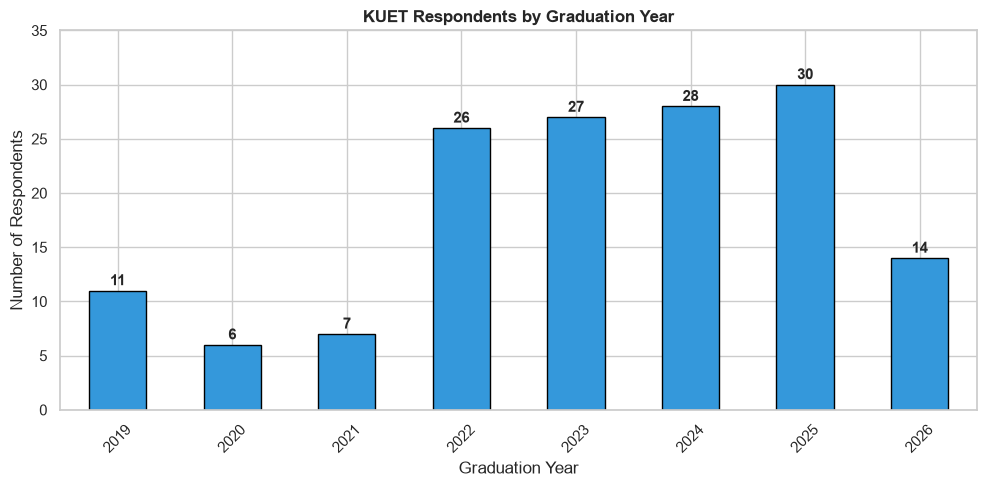

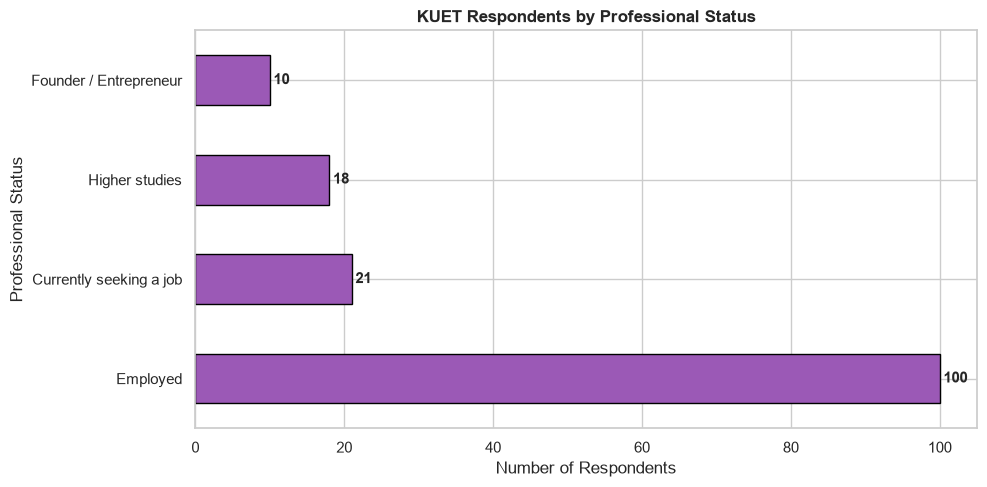

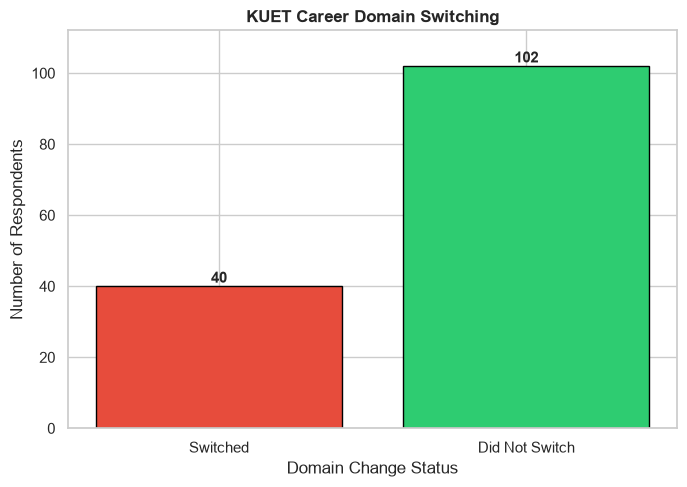

In [6]:
# Plot 1: KUET Graduation Batch
plt.figure(figsize=(10, 5))
batch_counts.plot(kind='bar', color='#3498db', edgecolor='black')
plt.title('KUET Respondents by Graduation Year', fontweight='bold')
plt.xlabel('Graduation Year')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45)
batch_axis_max = int(np.ceil(batch_counts.max() / 5) * 5) + 5
plt.ylim(0, batch_axis_max)
for i, value in enumerate(batch_counts.values):
    plt.text(i, value + 0.5, str(value), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 2: KUET Professional Status
plt.figure(figsize=(10, 5))
status_counts.plot(kind='barh', color='#9b59b6', edgecolor='black')
plt.title('KUET Respondents by Professional Status', fontweight='bold')
plt.xlabel('Number of Respondents')
plt.ylabel('Professional Status')
status_axis_max = int(np.ceil(status_counts.max() / 5) * 5) + 5
plt.xlim(0, status_axis_max)
for i, value in enumerate(status_counts.values):
    plt.text(value + 0.5, i, str(value), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 3: KUET Career Domain Switching
plt.figure(figsize=(7, 5))
labels = domain_switch_counts.index.tolist()
values = domain_switch_counts.values.astype(int)
plt.bar(labels, values, color=['#e74c3c', '#2ecc71'], edgecolor='black')
plt.title('KUET Career Domain Switching', fontweight='bold')
plt.xlabel('Domain Change Status')
plt.ylabel('Number of Respondents')
plt.ylim(0, max(values) + 10)
for i, value in enumerate(values):
    plt.text(i, value + 1, str(value), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Target Variable Definition & 5-Class Satisfaction Labels
### Preprocessing Rationale:
1. **Target Column (Col 18)**: Survey Question 14 (*"How satisfied are you with your current career path?"*), originally rated on a 1–5 Likert scale.
2. **Missing Target Handling**: Missing target rows are strictly dropped to avoid synthetic label noise.
3. **Five Satisfaction Classes**:
   - **Very Dissatisfied** (Rating 1)
   - **Dissatisfied** (Rating 2)
   - **Neutral** (Rating 3)
   - **Satisfied** (Rating 4)
   - **Very Satisfied** (Rating 5)
4. **All 5 Likert labels retained** for complete multi-class fidelity.

In [7]:
# Step 4.1: Identify target column
target_col_raw = kuet_raw_df.columns[18]

# Step 4.2: Drop missing target rows
df = kuet_raw_df.dropna(subset=[target_col_raw]).reset_index(drop=True)
print(f"Valid Supervised Modeling Instances (KUET): N = {len(df)}")

# Step 4.3: Preserve all 5 Satisfaction Levels with descriptive labels
satisfaction_labels = {
    1.0: 'Very Dissatisfied',
    2.0: 'Dissatisfied',
    3.0: 'Neutral',
    4.0: 'Satisfied',
    5.0: 'Very Satisfied'
}
df['Target_5Class'] = df[target_col_raw].map(satisfaction_labels)

# Step 4.4: Display Target Distribution Table
target_summary = pd.DataFrame({
    'Raw Likert Scale Values': ['Rating 1', 'Rating 2', 'Rating 3', 'Rating 4', 'Rating 5'],
    'Instance Count (N)': [
        (df['Target_5Class'] == label).sum() for label in satisfaction_labels.values()
    ],
    'Proportion (%)': [
        f"{(df['Target_5Class'] == label).mean():.1%}" for label in satisfaction_labels.values()
    ]
}, index=list(satisfaction_labels.values()))

print("\n=== KUET 5-Class Career Satisfaction Target Distribution ===")
display(target_summary)

Valid Supervised Modeling Instances (KUET): N = 143

=== KUET 5-Class Career Satisfaction Target Distribution ===


,Raw Likert Scale Values,Instance Count (N),Proportion (%)
Very Dissatisfied,Rating 1,2,1.4%
Dissatisfied,Rating 2,15,10.5%
Neutral,Rating 3,28,19.6%
Satisfied,Rating 4,57,39.9%
Very Satisfied,Rating 5,41,28.7%


## 5. Common Characteristics of Rating-5 KUET Graduates
We analyze KUET graduates reporting the highest career satisfaction (**Rating 5: 'Very Satisfied'**).

In [8]:
# Rating 5 respondents in KUET
rating_5_df = df[df[target_col_raw] == 5].copy()
print(f"KUET Rating 5 Respondents: N = {len(rating_5_df)}")

# Selected numeric characteristics of Rating 5 KUET respondents
numeric_characteristic_cols = [
    'University_Studies_Effect', 'Help_Lecture', 'Help_Lab',
    'Help_Thesis_Group_Work', 'Help_Club_Activities', 'Help_Alumni_Network',
    'Software_Projects_Built', 'Problem_Solving_Ability',
    'AI_Programming_Reliance'
]
rating_5_numeric = rating_5_df[numeric_characteristic_cols].apply(
    pd.to_numeric, errors='coerce'
)
print("=== Numeric & Likert Metrics of KUET Rating 5 Graduates ===")
display(rating_5_numeric.describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(2))

# Categorical modal traits among Rating 5 KUET graduates
categorical_cols = [
    'Professional_Status', 'Club_Participation',
    'Internship_Part_Time_Freelance', 'GitHub_Maintenance',
    'Programming_Contest_Involvement', 'First_Career_Domain',
    'Current_Career_Domain', 'Future_Domain_Shift',
    'AI_Usage_Frequency', 'AI_Concerns_Opinion'
]

common_characteristics = {}
for col in categorical_cols:
    mode_values = rating_5_df[col].dropna().mode()
    if len(mode_values) > 0:
        common_characteristics[col] = mode_values.iloc[0]

common_characteristics_df = pd.DataFrame(
    list(common_characteristics.items()),
    columns=['Feature', 'Most Common Response (Mode)']
)
print("\n=== Modal Traits of KUET Rating 5 Graduates ===")
display(common_characteristics_df)

KUET Rating 5 Respondents: N = 41
=== Numeric & Likert Metrics of KUET Rating 5 Graduates ===


,count,mean,std,min,25%,50%,75%,max
University_Studies_Effect,41.0,3.39,1.67,0.0,2.0,4.0,5.0,5.0
Help_Lecture,41.0,3.27,1.53,1.0,2.0,3.0,5.0,5.0
Help_Lab,41.0,2.41,1.12,1.0,2.0,2.0,3.0,5.0
Help_Thesis_Group_Work,41.0,3.05,1.50,1.0,2.0,3.0,4.0,5.0
Help_Club_Activities,41.0,2.59,1.47,1.0,1.0,2.0,4.0,5.0
Help_Alumni_Network,41.0,3.05,1.45,1.0,2.0,3.0,4.0,5.0
Software_Projects_Built,9.0,3.00,1.32,1.0,2.0,4.0,4.0,4.0
Problem_Solving_Ability,41.0,3.32,0.96,1.0,3.0,3.0,4.0,5.0
AI_Programming_Reliance,41.0,3.51,1.16,1.0,3.0,4.0,4.0,5.0



=== Modal Traits of KUET Rating 5 Graduates ===


,Feature,Most Common Response (Mode)
0,Professional_Status,Employed
1,Club_Participation,Programming
2,Internship_Part_Time_Freelance,No
3,GitHub_Maintenance,Actively maintained
4,Programming_Contest_Involvement,Occasionally
5,First_Career_Domain,Software Engineer
6,Current_Career_Domain,Software Engineer
7,Future_Domain_Shift,No
8,AI_Usage_Frequency,Constantly
9,AI_Concerns_Opinion,Neutral


## 6. Exploratory Impact Analysis: Column 19 (Domain Shift Intent)
We examine the relationship between **Domain Shift Intent (Column 19: *"Do you expect to shift to a different domain in the future?"*)** and **Career Satisfaction** in the KUET cohort.

=== Cross-Tabulation: Domain Shift Intent (Col 19) vs Target in KUET (Counts) ===


Target_5Class,Dissatisfied,Neutral,Satisfied,Very Dissatisfied,Very Satisfied,All
Future_Domain_Shift,,,,,,
Maybe,1,5,15,0,5,26
No,7,15,30,1,31,84
Not Specified,0,0,0,0,1,1
Yes,7,8,12,1,4,32
All,15,28,57,2,41,143



=== Row-Wise Percentage Distribution (%) ===


Target_5Class,Dissatisfied,Neutral,Satisfied,Very Dissatisfied,Very Satisfied
Future_Domain_Shift,,,,,
Maybe,3.8,19.2,57.7,0.0,19.2
No,8.3,17.9,35.7,1.2,36.9
Not Specified,0.0,0.0,0.0,0.0,100.0
Yes,21.9,25.0,37.5,3.1,12.5


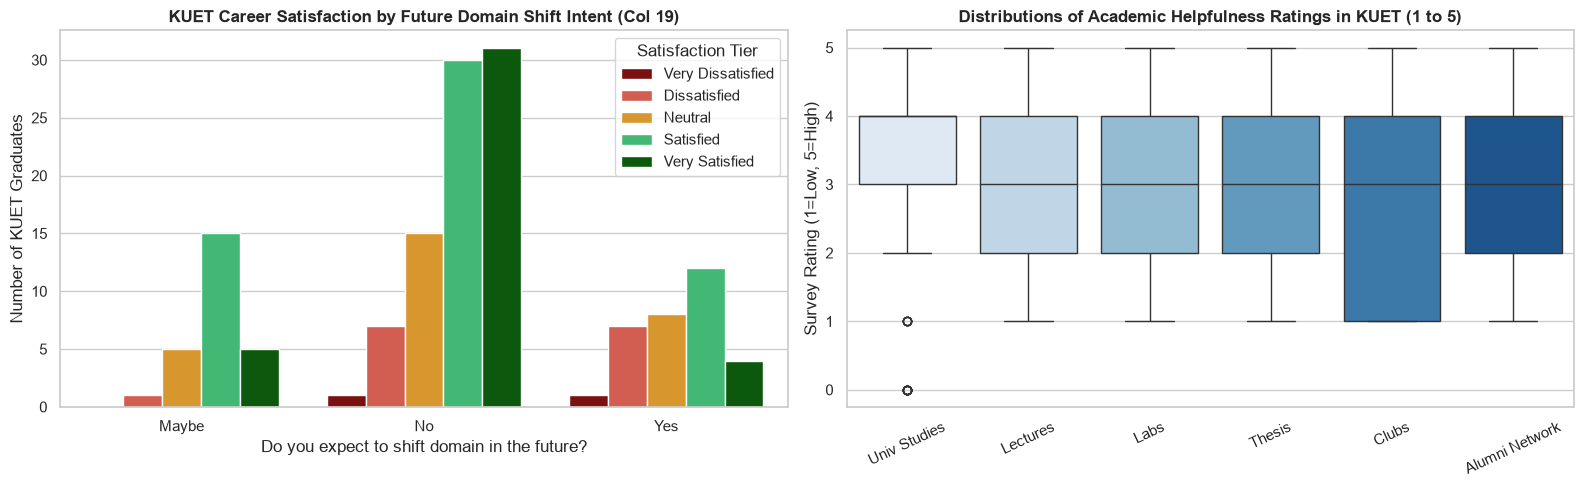

In [9]:
col19_name = 'Future_Domain_Shift'

# Cross-tabulation table
ct_counts = pd.crosstab(df[col19_name].fillna('Not Specified'), df['Target_5Class'], margins=True)
ct_perc = pd.crosstab(df[col19_name].fillna('Not Specified'), df['Target_5Class'], normalize='index') * 100

print("=== Cross-Tabulation: Domain Shift Intent (Col 19) vs Target in KUET (Counts) ===")
display(ct_counts)
print("\n=== Row-Wise Percentage Distribution (%) ===")
display(ct_perc.round(1))

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

hue_order_active = [l for l in satisfaction_labels.values() if l in df['Target_5Class'].unique()]
palette_map = {'Very Dissatisfied': '#8b0000', 'Dissatisfied': '#e74c3c', 'Neutral': '#f39c12', 'Satisfied': '#2ecc71', 'Very Satisfied': '#006400'}
active_palette = [palette_map[l] for l in hue_order_active]

sns.countplot(data=df, x=col19_name, hue='Target_5Class', hue_order=hue_order_active,
              palette=active_palette, ax=axes[0])
axes[0].set_title('KUET Career Satisfaction by Future Domain Shift Intent (Col 19)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Do you expect to shift domain in the future?')
axes[0].set_ylabel('Number of KUET Graduates')
axes[0].legend(title='Satisfaction Tier')

# Academic components boxplots
acad_cols_raw = ['University_Studies_Effect', 'Help_Lecture', 'Help_Lab', 'Help_Thesis_Group_Work', 'Help_Club_Activities', 'Help_Alumni_Network']
acad_names = ['Univ Studies', 'Lectures', 'Labs', 'Thesis', 'Clubs', 'Alumni Network']
acad_df = df[acad_cols_raw].apply(pd.to_numeric, errors='coerce')
acad_df.columns = acad_names

sns.boxplot(data=acad_df, palette='Blues', ax=axes[1])
axes[1].set_title('Distributions of Academic Helpfulness Ratings in KUET (1 to 5)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Survey Rating (1=Low, 5=High)')
axes[1].set_xticklabels(acad_names, rotation=25)

plt.tight_layout()
plt.show()

## 7. Common Characteristics of Low-Satisfaction KUET Graduates (Ratings 1 & 2)
We isolate and profile KUET graduates reporting lower satisfaction (**Rating 1: 'Very Dissatisfied'** and **Rating 2: 'Dissatisfied'**).

=== KUET Low-Satisfaction Cohort Verification ===
Total Valid KUET Survey Responses: N = 143
Low-Satisfaction Students (Ratings 1 & 2): N = 17 (11.9% of total)
  - Rating 1 (Very Dissatisfied): N = 2 (1.4%)
  - Rating 2 (Dissatisfied)     : N = 15 (10.5%)

=== Numeric & Likert Characteristics of KUET Low-Satisfaction Graduates ===


,count,mean,std,min,25%,50%,75%,max
University_Studies_Effect,17.0,3.29,1.49,0.0,2.0,4.0,4.0,5.0
Help_Lecture,17.0,2.47,1.46,1.0,1.0,2.0,4.0,5.0
Help_Lab,17.0,2.59,1.42,1.0,1.0,2.0,4.0,5.0
Help_Thesis_Group_Work,17.0,3.18,1.38,1.0,2.0,3.0,4.0,5.0
Help_Club_Activities,17.0,2.47,1.18,1.0,1.0,3.0,3.0,5.0
Help_Alumni_Network,17.0,2.65,1.58,1.0,1.0,2.0,4.0,5.0
Software_Projects_Built,3.0,3.67,0.58,3.0,3.5,4.0,4.0,4.0
Problem_Solving_Ability,17.0,3.47,0.94,2.0,3.0,3.0,4.0,5.0
AI_Programming_Reliance,17.0,4.00,1.06,2.0,3.0,4.0,5.0,5.0


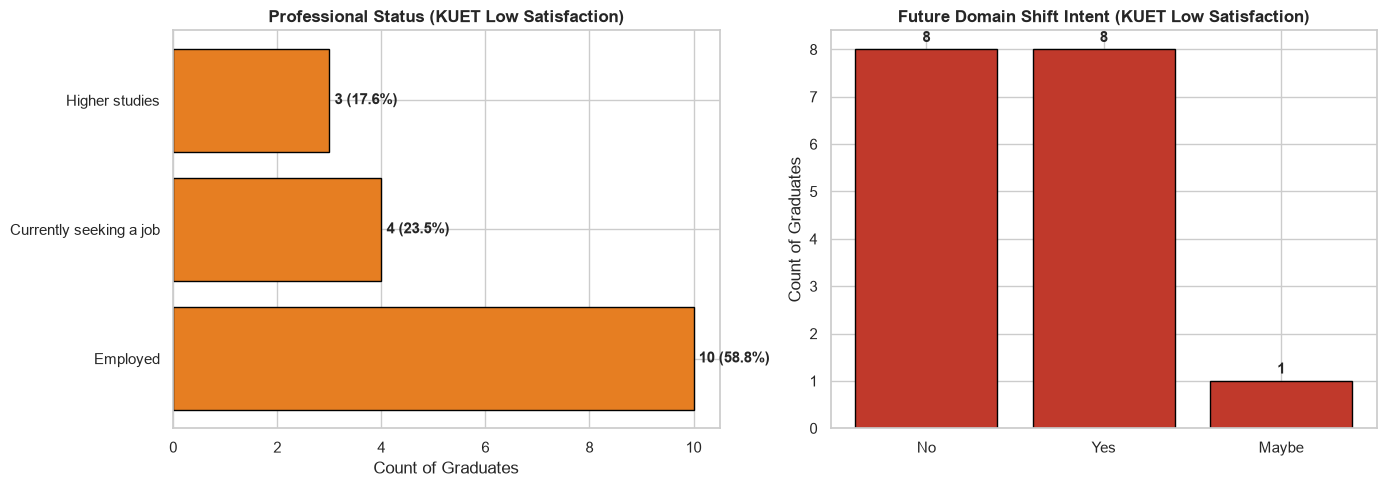

In [10]:
# Dynamic extraction of the Low-Satisfaction cohort (Ratings 1 & 2)
target_num_col = pd.to_numeric(df[target_col_raw], errors='coerce')
low_sat_mask = target_num_col.isin([1, 2])
low_sat_df = df[low_sat_mask].copy()

n_total = len(df)
n_low = len(low_sat_df)
n_r1 = int((target_num_col == 1).sum())
n_r2 = int((target_num_col == 2).sum())
pct_low = (n_low / n_total) * 100 if n_total > 0 else 0

print("=== KUET Low-Satisfaction Cohort Verification ===")
print(f"Total Valid KUET Survey Responses: N = {n_total}")
print(f"Low-Satisfaction Students (Ratings 1 & 2): N = {n_low} ({pct_low:.1f}% of total)")
print(f"  - Rating 1 (Very Dissatisfied): N = {n_r1} ({(n_r1/n_total)*100:.1f}%)")
print(f"  - Rating 2 (Dissatisfied)     : N = {n_r2} ({(n_r2/n_total)*100:.1f}%)")

# Numeric summary for Low-Satisfaction graduates
low_sat_numeric = low_sat_df[numeric_characteristic_cols].apply(pd.to_numeric, errors='coerce')
low_num_summary = low_sat_numeric.describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
print("\n=== Numeric & Likert Characteristics of KUET Low-Satisfaction Graduates ===")
display(low_num_summary.round(2))

# Visual breakdown of Professional Status and Future Domain Shift intent in Low Sat cohort
if n_low > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    status_counts_low = low_sat_df['Professional_Status'].value_counts()
    axes[0].barh(status_counts_low.index, status_counts_low.values, color='#e67e22', edgecolor='black')
    axes[0].set_title('Professional Status (KUET Low Satisfaction)', fontweight='bold')
    axes[0].set_xlabel('Count of Graduates')
    for i, v in enumerate(status_counts_low.values):
        axes[0].text(v + 0.1, i, f"{v} ({(v/n_low)*100:.1f}%)", va='center', fontweight='bold')

    shift_counts_low = low_sat_df['Future_Domain_Shift'].value_counts()
    axes[1].bar(shift_counts_low.index, shift_counts_low.values, color='#c0392b', edgecolor='black')
    axes[1].set_title('Future Domain Shift Intent (KUET Low Satisfaction)', fontweight='bold')
    axes[1].set_ylabel('Count of Graduates')
    for container in axes[1].containers:
        axes[1].bar_label(container, padding=3, fontweight='bold')

    plt.tight_layout()
    plt.show()

## 8. Identifying Features Most Strongly Associated with Career Satisfaction in KUET
We systematically test features for statistical association with career satisfaction across all Likert levels:
- **Ordinal / Numeric Features**: Tested via non-parametric **Kruskal-Wallis $H$-tests** and **Spearman rank correlation** ($\rho$).
- **Nominal Categorical Features**: Tested via **Pearson Chi-Square ($\chi^2$)** tests and **Cramér's $V$**.
- **Multiple-Testing Correction**: Applied via **Benjamini-Hochberg (BH) False Discovery Rate (FDR)** procedure.

In [11]:
# Prepare encoded ordinal metrics and target for statistical association testing
proj_map = {'0': 0, 0: 0, 1: 1, '1': 1, 2: 2, '2': 2, 3: 3, '3': 3, 4: 4, '4': 4, '5 or more': 5}
gh_map = {'Rarely used': 0, 'Occasionally maintained': 1, 'Actively maintained': 2}
contest_map = {'Never': 0, 'Occasionally': 1, 'Regularly': 2, 'Competitively': 3}
shift_map = {'No': 0, 'Maybe': 1, 'Yes': 2}
ai_freq_map = {'Never': 0, 'Rarely': 1, 'Weekly': 2, 'Frequently': 2, 'Constantly': 3, 'Daily': 3}

df_assoc = df.copy()
df_assoc['Satisfaction_Num'] = pd.to_numeric(df_assoc[target_col_raw], errors='coerce')
df_assoc['Projects_Num'] = df_assoc['Software_Projects_Built'].map(proj_map).fillna(2)
df_assoc['GitHub_Num'] = df_assoc['GitHub_Maintenance'].map(gh_map).fillna(1)
df_assoc['Contest_Num'] = df_assoc['Programming_Contest_Involvement'].map(contest_map).fillna(0)
df_assoc['Shift_Intent_Num'] = df_assoc['Future_Domain_Shift'].map(shift_map).fillna(1)
df_assoc['AI_Freq_Num'] = df_assoc['AI_Usage_Frequency'].map(ai_freq_map).fillna(1)
df_assoc['Domain_Switched_Num'] = (df_assoc['First_Career_Domain'].fillna('') != df_assoc['Current_Career_Domain'].fillna('')).astype(int)

# 1. Ordinal & Numeric Features Battery
numeric_ord_cols = [
    ('Shift_Intent_Num', 'Future Domain Shift Intent (0-2)'),
    ('Help_Lab', 'Laboratory Courses Helpfulness (1-5)'),
    ('Help_Thesis_Group_Work', 'Thesis & Group Works Helpfulness (1-5)'),
    ('Problem_Solving_Ability', 'Problem-Solving Ability (1-5)'),
    ('AI_Programming_Reliance', 'AI Programming Reliance (1-5)'),
    ('University_Studies_Effect', 'University Studies Effect (0-5)'),
    ('Projects_Num', 'Software Projects Built (0-5)'),
    ('Help_Alumni_Network', 'Alumni Network Helpfulness (1-5)'),
    ('Contest_Num', 'Contest Involvement (0-3)'),
    ('GitHub_Num', 'GitHub Maintenance (0-2)'),
    ('Help_Club_Activities', 'Club Activities Helpfulness (1-5)'),
    ('Help_Lecture', 'Lecture Courses Helpfulness (1-5)'),
    ('AI_Freq_Num', 'AI Usage Frequency (0-3)'),
    ('Domain_Switched_Num', 'Domain Switched (0/1)')
]

association_records = []
for col_id, col_name in numeric_ord_cols:
    valid_mask = df_assoc[col_id].notna() & df_assoc['Satisfaction_Num'].notna()
    sub_data = df_assoc[valid_mask]
    groups = [sub_data[sub_data['Satisfaction_Num'] == s][col_id].values for s in [1, 2, 3, 4, 5]]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) > 1:
        kw_stat, kw_p = stats.kruskal(*groups)
    else:
        kw_stat, kw_p = 0.0, 1.0
    rho, sp_p = stats.spearmanr(sub_data[col_id], sub_data['Satisfaction_Num'])
    
    association_records.append({
        'Feature Name': col_name,
        'Variable Type': 'Ordinal / Numeric',
        'Primary Test': 'Kruskal-Wallis H',
        'Test Statistic': round(kw_stat, 2),
        'p_raw': kw_p,
        'Effect Size Metric': f"Spearman rho = {rho:+.3f}" if not np.isnan(rho) else "N/A",
        'Effect_Size_Val': abs(rho) if not np.isnan(rho) else 0.0
    })

# 2. Nominal Categorical Features Battery
nominal_cols = [
    ('Professional_Status', 'Professional Status'),
    ('Future_Domain_Shift', 'Future Domain Shift Intent (Categorical)'),
    ('AI_Concerns_Opinion', 'AI Concerns / Opinions'),
    ('Current_Career_Domain', 'Current Career Domain'),
    ('First_Career_Domain', 'First Career Domain'),
    ('Internship_Part_Time_Freelance', 'Internship / Freelance Experience')
]

for col_id, col_name in nominal_cols:
    ct = pd.crosstab(df[col_id].fillna('Not Specified'), df_assoc['Satisfaction_Num'])
    if ct.shape[0] > 1 and ct.shape[1] > 1:
        chi2, p, dof, _ = stats.chi2_contingency(ct)
        n = ct.values.sum()
        cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    else:
        chi2, p, cramers_v = 0.0, 1.0, 0.0
    
    association_records.append({
        'Feature Name': col_name,
        'Variable Type': 'Nominal Categorical',
        'Primary Test': 'Chi-Square (Chi2)',
        'Test Statistic': round(chi2, 2),
        'p_raw': p,
        'Effect Size Metric': f"Cramers V = {cramers_v:.3f}",
        'Effect_Size_Val': cramers_v
    })

# 3. Benjamini-Hochberg FDR Multiple-Testing Correction
assoc_df = pd.DataFrame(association_records)
assoc_df['p_adj_fdr'] = stats.false_discovery_control(assoc_df['p_raw'], method='bh')
assoc_df['FDR Significance'] = assoc_df['p_adj_fdr'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
)

# Sort leaderboard by statistical association strength (p_raw)
assoc_df = assoc_df.sort_values('p_raw').reset_index(drop=True)
display_df = assoc_df[['Feature Name', 'Variable Type', 'Primary Test', 'Test Statistic',
                       'p_raw', 'p_adj_fdr', 'FDR Significance', 'Effect Size Metric']].copy()
display_df['p_raw'] = display_df['p_raw'].apply(lambda x: f"{x:.4e}" if x < 0.0001 else f"{x:.4f}")
display_df['p_adj_fdr'] = display_df['p_adj_fdr'].apply(lambda x: f"{x:.4e}" if x < 0.0001 else f"{x:.4f}")

print("=== Leaderboard: Features Most Strongly Associated with Career Satisfaction in KUET ===")
print("Note: p_adj_fdr computed via Benjamini-Hochberg procedure across all tested features.")
display(display_df)

=== Leaderboard: Features Most Strongly Associated with Career Satisfaction in KUET ===
Note: p_adj_fdr computed via Benjamini-Hochberg procedure across all tested features.


,Feature Name,Variable Type,Primary Test,Test Statistic,p_raw,p_adj_fdr,FDR Significance,Effect Size Metric
0,Software Projects Built (0-5),Ordinal / Numeric,Kruskal-Wallis H,11.61,0.0205,0.4093,ns,Spearman rho = -0.001
1,Future Domain Shift Intent (0-2),Ordinal / Numeric,Kruskal-Wallis H,8.50,0.0748,0.4897,ns,Spearman rho = -0.230
2,Laboratory Courses Helpfulness (1-5),Ordinal / Numeric,Kruskal-Wallis H,7.55,0.1097,0.4897,ns,Spearman rho = -0.079
3,Professional Status,Nominal Categorical,Chi-Square (Chi2),18.10,0.1128,0.4897,ns,Cramers V = 0.205
4,Future Domain Shift Intent (Categorical),Nominal Categorical,Chi-Square (Chi2),17.78,0.1224,0.4897,ns,Cramers V = 0.204
5,AI Concerns / Opinions,Nominal Categorical,Chi-Square (Chi2),11.48,0.1759,0.5863,ns,Cramers V = 0.200
6,AI Usage Frequency (0-3),Ordinal / Numeric,Kruskal-Wallis H,5.51,0.2388,0.6308,ns,Spearman rho = -0.119
7,Problem-Solving Ability (1-5),Ordinal / Numeric,Kruskal-Wallis H,5.31,0.2571,0.6308,ns,Spearman rho = +0.056
8,AI Programming Reliance (1-5),Ordinal / Numeric,Kruskal-Wallis H,4.98,0.2898,0.6308,ns,Spearman rho = -0.034
9,Alumni Network Helpfulness (1-5),Ordinal / Numeric,Kruskal-Wallis H,4.74,0.3154,0.6308,ns,Spearman rho = +0.124


## 9. Comprehensive Bivariate Correlation Analysis (KUET)
We conduct Spearman rank correlation ($\rho$) and Pearson correlation ($r$) analyses across all legitimate numeric and ordinal survey dimensions.

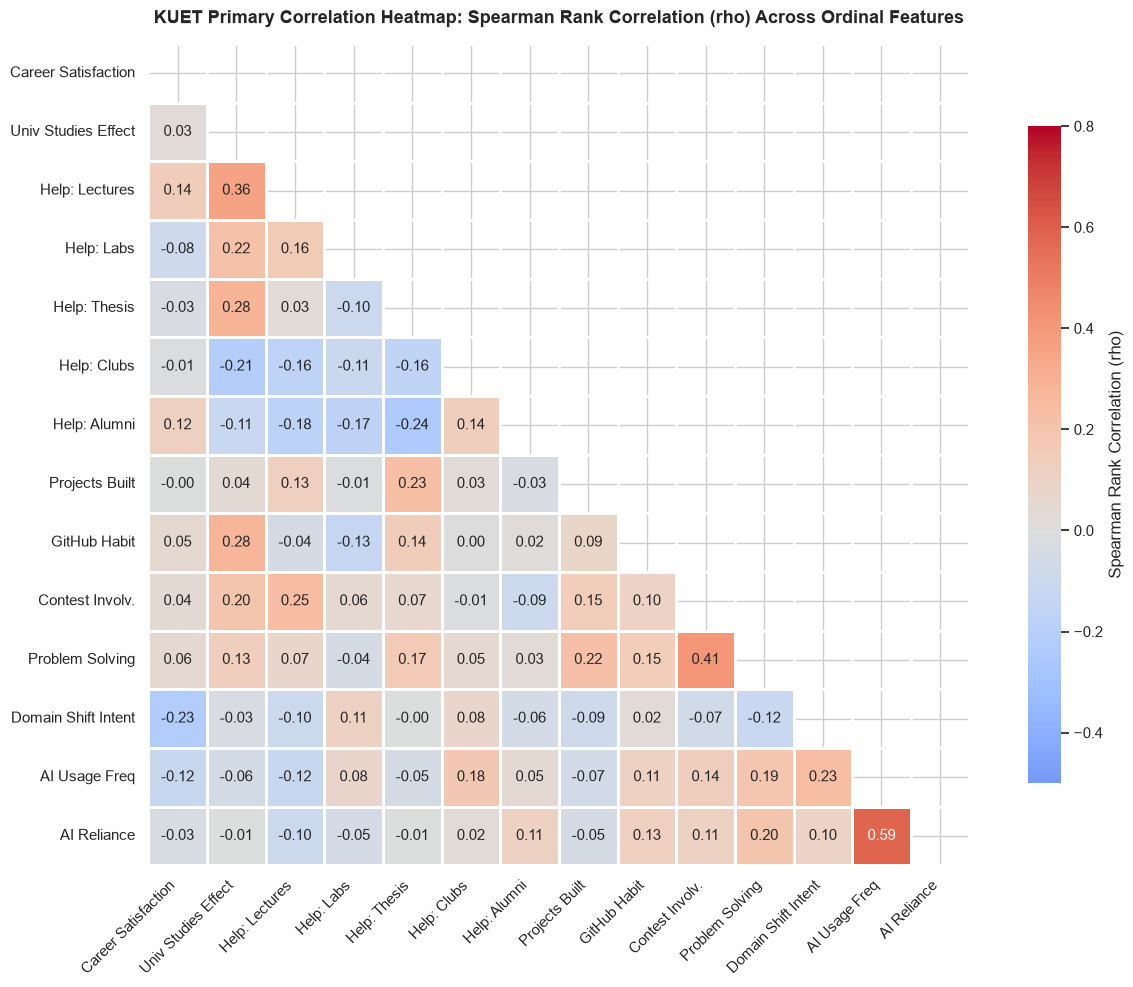

=== Top Synergy & Correlation Clusters in KUET Cohort ===


,Feature Pair,Spearman rho,Relationship Type
0,AI Reliance & AI Usage Freq,0.586,Strong Positive Synergy
1,Problem Solving & Contest Involv.,0.407,Strong Positive Synergy
2,Help: Lectures & Univ Studies Effect,0.358,Strong Positive Synergy
3,Help: Thesis & Univ Studies Effect,0.284,Strong Positive Synergy
4,GitHub Habit & Univ Studies Effect,0.279,Strong Positive Synergy
5,Contest Involv. & Help: Lectures,0.248,Strong Positive Synergy
6,Help: Alumni & Help: Thesis,-0.238,Inverse Association
7,Domain Shift Intent & Career Satisfaction,-0.230,Inverse Association
8,Help: Clubs & Univ Studies Effect,-0.213,Inverse Association
9,Help: Alumni & Help: Lectures,-0.175,Inverse Association


In [12]:
# Construct valid numerical/ordinal correlation dataset
corr_feature_cols = [
    'Satisfaction_Num', 'University_Studies_Effect', 'Help_Lecture', 'Help_Lab',
    'Help_Thesis_Group_Work', 'Help_Club_Activities', 'Help_Alumni_Network',
    'Projects_Num', 'GitHub_Num', 'Contest_Num', 'Problem_Solving_Ability',
    'Shift_Intent_Num', 'AI_Freq_Num', 'AI_Programming_Reliance'
]
corr_feature_names = [
    'Career Satisfaction', 'Univ Studies Effect', 'Help: Lectures', 'Help: Labs',
    'Help: Thesis', 'Help: Clubs', 'Help: Alumni', 'Projects Built',
    'GitHub Habit', 'Contest Involv.', 'Problem Solving',
    'Domain Shift Intent', 'AI Usage Freq', 'AI Reliance'
]

corr_data = df_assoc[corr_feature_cols].apply(pd.to_numeric, errors='coerce')
corr_data.columns = corr_feature_names

# Compute primary Spearman rank correlation & Pearson correlation
spearman_corr_mat = corr_data.corr(method='spearman')
pearson_corr_mat = corr_data.corr(method='pearson')

# Visualization: Primary Spearman Correlation Heatmap
plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(spearman_corr_mat, dtype=bool))

sns.heatmap(spearman_corr_mat, mask=mask, cmap='coolwarm', vmin=-0.50, vmax=0.80, center=0,
            annot=True, fmt='.2f', square=True, linewidths=0.8,
            cbar_kws={"shrink": 0.8, "label": "Spearman Rank Correlation (rho)"})
plt.title('KUET Primary Correlation Heatmap: Spearman Rank Correlation (rho) Across Ordinal Features',
          fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Top synergy pairs
upper_tri = spearman_corr_mat.where(np.triu(np.ones(spearman_corr_mat.shape), k=1).astype(bool))
unstacked_corr = upper_tri.unstack().dropna()
top_positive = unstacked_corr.sort_values(ascending=False).head(6)
top_negative = unstacked_corr.sort_values().head(4)

corr_summary_df = pd.DataFrame({
    'Feature Pair': [f"{idx[0]} & {idx[1]}" for idx in top_positive.index],
    'Spearman rho': top_positive.values.round(3),
    'Relationship Type': 'Strong Positive Synergy'
})
neg_summary_df = pd.DataFrame({
    'Feature Pair': [f"{idx[0]} & {idx[1]}" for idx in top_negative.index],
    'Spearman rho': top_negative.values.round(3),
    'Relationship Type': 'Inverse Association'
})

print("=== Top Synergy & Correlation Clusters in KUET Cohort ===")
display(pd.concat([corr_summary_df, neg_summary_df]).reset_index(drop=True))

## 10. Statistical Hypothesis Testing & Academic Component Benchmarking
We benchmark **Level 5 ('Very Satisfied')** KUET graduates against **Low-Satisfaction (Ratings 1 & 2)** KUET graduates across the five central academic components using the non-parametric **Mann-Whitney U test** and **Rank-Biserial Correlation**.

Verified KUET Cohort Sizes: Level 5 (Very Satisfied): N = 41 | Low Satisfaction (Ratings 1 & 2): N = 17
=== KUET Statistical Diagnostic Table: Satisfaction Level 5 vs Low Satisfaction ===


,Academic Dimension,Level 5 Mean +/- SD,Low Sat Mean +/- SD,Diff (Lvl5 - Low),Mann-Whitney U,p_raw (MWU),p_adj_fdr,Rank-Biserial r,Welch t (suppl),Cohen d (suppl),FDR Sig
0,Lecture Courses,3.27 +/- 1.53,2.47 +/- 1.46,+0.80,450.0,0.0769,0.3846,-0.291,1.86,0.53,ns
1,Laboratory Courses,2.41 +/- 1.12,2.59 +/- 1.42,-0.17,332.0,0.7772,0.8877,0.047,-0.45,-0.14,ns
2,Thesis & Group Works,3.05 +/- 1.50,3.18 +/- 1.38,-0.13,336.0,0.8335,0.8877,0.036,-0.31,-0.09,ns
3,Club Activities,2.59 +/- 1.47,2.47 +/- 1.18,+0.11,357.0,0.8877,0.8877,-0.024,0.31,0.08,ns
4,Alumni Network,3.05 +/- 1.45,2.65 +/- 1.58,+0.40,403.0,0.3459,0.8647,-0.156,0.90,0.27,ns


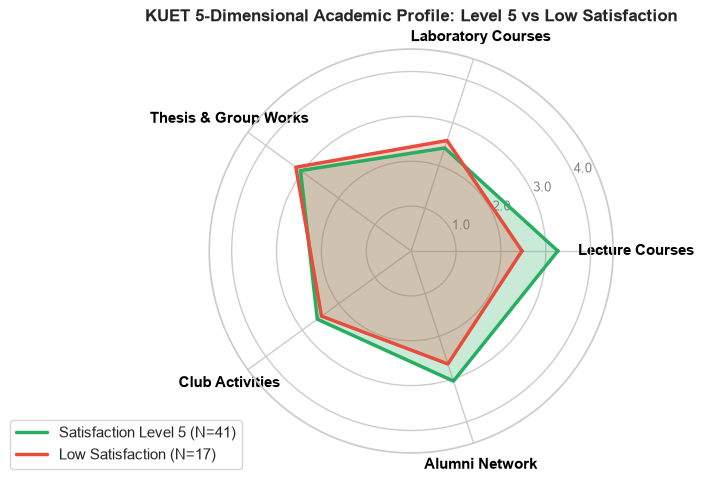

In [13]:
# Dynamic extraction and sample size verification
sat5_mask = df_assoc['Satisfaction_Num'] == 5
low_sat_mask = df_assoc['Satisfaction_Num'].isin([1, 2])

group_sat5 = df_assoc[sat5_mask]
group_low = df_assoc[low_sat_mask]

n_5 = len(group_sat5)
n_low = len(group_low)
print(f"Verified KUET Cohort Sizes: Level 5 (Very Satisfied): N = {n_5} | Low Satisfaction (Ratings 1 & 2): N = {n_low}")

acad_benchmark_dims = [
    ('Help_Lecture', 'Lecture Courses'),
    ('Help_Lab', 'Laboratory Courses'),
    ('Help_Thesis_Group_Work', 'Thesis & Group Works'),
    ('Help_Club_Activities', 'Club Activities'),
    ('Help_Alumni_Network', 'Alumni Network')
]

comp_records = []
p_raw_comp = []

for col, name in acad_benchmark_dims:
    s5 = pd.to_numeric(group_sat5[col], errors='coerce').dropna()
    slow = pd.to_numeric(group_low[col], errors='coerce').dropna()
    
    # Mann-Whitney U test
    u_stat, u_p = stats.mannwhitneyu(s5, slow, alternative='two-sided')
    p_raw_comp.append(u_p)
    
    n1, n2 = len(s5), len(slow)
    rank_biserial = 1 - (2 * u_stat) / (n1 * n2) if (n1 * n2) > 0 else 0
    
    # Supplementary Welch's t-test and Cohen's d
    t_stat, t_p = stats.ttest_ind(s5, slow, equal_var=False)
    s1, s2 = np.std(s5, ddof=1), np.std(slow, ddof=1)
    pooled_sd = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2)) if (n1 + n2 > 2) else 1
    cohen_d = (s5.mean() - slow.mean()) / pooled_sd if pooled_sd != 0 else 0
    
    comp_records.append({
        'Academic Dimension': name,
        'Level 5 Mean +/- SD': f"{s5.mean():.2f} +/- {s1:.2f}",
        'Low Sat Mean +/- SD': f"{slow.mean():.2f} +/- {s2:.2f}",
        'Diff (Lvl5 - Low)': f"{s5.mean() - slow.mean():+.2f}",
        'Mann-Whitney U': round(u_stat, 1),
        'p_raw (MWU)': u_p,
        'Rank-Biserial r': round(rank_biserial, 3),
        'Welch t (suppl)': round(t_stat, 2),
        'Cohen d (suppl)': round(cohen_d, 2)
    })

# Benjamini-Hochberg FDR correction
p_adj_comp = stats.false_discovery_control(p_raw_comp, method='bh')
for i, p_adj in enumerate(p_adj_comp):
    comp_records[i]['p_adj_fdr'] = p_adj
    comp_records[i]['FDR Sig'] = '***' if p_adj < 0.001 else ('**' if p_adj < 0.01 else ('*' if p_adj < 0.05 else 'ns'))

comp_table = pd.DataFrame(comp_records)
display_comp = comp_table[['Academic Dimension', 'Level 5 Mean +/- SD', 'Low Sat Mean +/- SD',
                           'Diff (Lvl5 - Low)', 'Mann-Whitney U', 'p_raw (MWU)', 'p_adj_fdr',
                           'Rank-Biserial r', 'Welch t (suppl)', 'Cohen d (suppl)', 'FDR Sig']].copy()
display_comp['p_raw (MWU)'] = display_comp['p_raw (MWU)'].apply(lambda x: f"{x:.4f}")
display_comp['p_adj_fdr'] = display_comp['p_adj_fdr'].apply(lambda x: f"{x:.4f}")

print("=== KUET Statistical Diagnostic Table: Satisfaction Level 5 vs Low Satisfaction ===")
display(display_comp)

# 5-Dimensional Academic Profile Spider/Radar Chart
categories = [name for _, name in acad_benchmark_dims]
N = len(categories)
mean_s5 = [pd.to_numeric(group_sat5[col], errors='coerce').mean() for col, _ in acad_benchmark_dims]
mean_low = [pd.to_numeric(group_low[col], errors='coerce').mean() for col, _ in acad_benchmark_dims]

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
mean_s5_plot = mean_s5 + mean_s5[:1]
mean_low_plot = mean_low + mean_low[:1]

plt.figure(figsize=(7, 7))
ax = plt.subplot(111, polar=True)
plt.xticks(angles[:-1], categories, color='black', size=11, fontweight='bold')
ax.set_rlabel_position(25)
plt.yticks([1, 2, 3, 4], ["1.0", "2.0", "3.0", "4.0"], color="grey", size=9)
plt.ylim(0, 4.5)

ax.plot(angles, mean_s5_plot, linewidth=2.5, linestyle='solid', color='#27ae60', label=f'Satisfaction Level 5 (N={n_5})')
ax.fill(angles, mean_s5_plot, color='#27ae60', alpha=0.25)
ax.plot(angles, mean_low_plot, linewidth=2.5, linestyle='solid', color='#e74c3c', label=f'Low Satisfaction (N={n_low})')
ax.fill(angles, mean_low_plot, color='#e74c3c', alpha=0.25)

plt.title('KUET 5-Dimensional Academic Profile: Level 5 vs Low Satisfaction', fontweight='bold', size=12, pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.tight_layout()
plt.show()

## 11. Feature Preprocessing & Engineering
We construct the 20 clean, leak-free engineered feature matrix $X$ and the target vector $y$ for the KUET dataset.

In [14]:
# Step 11.1: Temporal Feature Engineering
years_since_grad = 2026 - pd.to_numeric(df['Graduation_Year'], errors='coerce').fillna(2022)

# Step 11.2: Career Domain Transitions
first_dom = df['First_Career_Domain'].fillna('Not Applicable')
curr_dom = df['Current_Career_Domain'].fillna('Not Applicable')
domain_switched = (first_dom != curr_dom).astype(int)

# Step 11.3: Domain Shift Intent (Col 19)
shift_intent_map = {'No': 0, 'Maybe': 1, 'Yes': 2}
domain_shift_intent = df['Future_Domain_Shift'].map(shift_intent_map).fillna(1)

# Step 11.4: Academic Helpfulness Distinct Sub-Dimensions
univ_effect = pd.to_numeric(df['University_Studies_Effect'], errors='coerce').fillna(3)
help_lecture = pd.to_numeric(df['Help_Lecture'], errors='coerce').fillna(3)
help_lab = pd.to_numeric(df['Help_Lab'], errors='coerce').fillna(3)
help_thesis = pd.to_numeric(df['Help_Thesis_Group_Work'], errors='coerce').fillna(3)
help_club = pd.to_numeric(df['Help_Club_Activities'], errors='coerce').fillna(3)
help_alumni = pd.to_numeric(df['Help_Alumni_Network'], errors='coerce').fillna(3)

# Step 11.5: Technical & Extracurricular Habits
club_counts = df['Club_Participation'].fillna('').apply(lambda x: len([c for c in str(x).split(',') if c.strip()]) if x else 0)
proj_map = {'0': 0, 0: 0, 1: 1, '1': 1, 2: 2, '2': 2, 3: 3, '3': 3, 4: 4, '4': 4, '5 or more': 5}
gh_map = {'Rarely used': 0, 'Occasionally maintained': 1, 'Actively maintained': 2}
contest_map = {'Never': 0, 'Occasionally': 1, 'Regularly': 2, 'Competitively': 3}

projects_num = df['Software_Projects_Built'].map(proj_map).fillna(2)
github_num = df['GitHub_Maintenance'].map(gh_map).fillna(1)
contest_num = df['Programming_Contest_Involvement'].map(contest_map).fillna(0)
ps_num = pd.to_numeric(df['Problem_Solving_Ability'], errors='coerce').fillna(3)
internship_bin = df['Internship_Part_Time_Freelance'].map({'Yes': 1, 'No': 0}).fillna(0)

# Step 11.6: AI Perceptions & Reliance
ai_freq_map = {'Never': 0, 'Rarely': 1, 'Weekly': 2, 'Frequently': 2, 'Constantly': 3, 'Daily': 3}
ai_opinion_map = {
    'Positive': 'Positive', 'Excited / Positive': 'Positive',
    'Neutral': 'Neutral', 'Neutral / Adaptable': 'Neutral',
    'Negative': 'Concerned', 'Anxious / Worried': 'Concerned', 'Threatened / Insecure': 'Concerned'
}

ai_usage_freq = df['AI_Usage_Frequency'].map(ai_freq_map).fillna(1)
ai_concerns = df['AI_Concerns_Opinion'].map(ai_opinion_map).fillna('Neutral')
ai_reliance = pd.to_numeric(df['AI_Programming_Reliance'], errors='coerce').fillna(2)

# Step 11.7: Assemble Final Feature Matrix X
X = pd.DataFrame({
    'Years_Since_Grad': years_since_grad,
    'Professional_Status': df['Professional_Status'].fillna('Employed'),
    'Univ_Studies_Effect': univ_effect,
    'Help_Lecture': help_lecture,
    'Help_Lab': help_lab,
    'Help_Thesis': help_thesis,
    'Help_Club': help_club,
    'Help_Alumni': help_alumni,
    'Club_Count': club_counts,
    'Internship_Exp': internship_bin,
    'Projects_Built': projects_num,
    'GitHub_Habit': github_num,
    'Contest_Involvement': contest_num,
    'Problem_Solving': ps_num,
    'Current_Domain': curr_dom,
    'Domain_Switched': domain_switched,
    'Domain_Shift_Intent': domain_shift_intent,
    'AI_Usage_Freq': ai_usage_freq,
    'AI_Concerns_Opinion': ai_concerns,
    'AI_Reliance': ai_reliance
})

y = df['Target_5Class']

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Final Engineered KUET Feature Matrix: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Numeric Features ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical Features ({len(categorical_cols)}): {categorical_cols}")
print(f"Total Missing Values: {X.isnull().sum().sum()}")
display(X.head(3))

Final Engineered KUET Feature Matrix: 143 samples, 20 features
Numeric Features (17): ['Years_Since_Grad', 'Univ_Studies_Effect', 'Help_Lecture', 'Help_Lab', 'Help_Thesis', 'Help_Club', 'Help_Alumni', 'Club_Count', 'Internship_Exp', 'Projects_Built', 'GitHub_Habit', 'Contest_Involvement', 'Problem_Solving', 'Domain_Switched', 'Domain_Shift_Intent', 'AI_Usage_Freq', 'AI_Reliance']
Categorical Features (3): ['Professional_Status', 'Current_Domain', 'AI_Concerns_Opinion']
Total Missing Values: 0


,Years_Since_Grad,Professional_Status,Univ_Studies_Effect,Help_Lecture,Help_Lab,Help_Thesis,Help_Club,Help_Alumni,Club_Count,Internship_Exp,Projects_Built,GitHub_Habit,Contest_Involvement,Problem_Solving,Current_Domain,Domain_Switched,Domain_Shift_Intent,AI_Usage_Freq,AI_Concerns_Opinion,AI_Reliance
0,4,Employed,4,4,3,5,2,1,3,1,5,2,3,3,Software Engineer,1,1.0,3,Neutral,4
1,7,Founder / Entrepreneur,4,5,1,4,3,2,3,0,5,1,0,4,Entrepreneurship,0,0.0,3,Positive,2
2,4,Employed,4,1,2,3,5,4,4,1,5,2,1,5,Data Science / ML / AI,1,0.0,3,Positive,1


## 12. Stratified Train/Test Split (80:20 Split) & Preprocessing Pipeline
- **Split Configuration**: **80% Training** and **20% Holdout Test** with class stratification.
- **Pipeline Scaling & Encoding**:
  - `StandardScaler()` applied to numerical features.
  - `OneHotEncoder(handle_unknown='ignore', sparse_output=False)` applied to categorical features.
  - Transformers are fitted strictly inside `Pipeline` instances to avoid data leakage.

In [15]:
# Step 12.1: Execute Stratified 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Step 12.2: Define ColumnTransformer Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

print(f"KUET Training Instances (80%): {len(X_train)}")
print(f"KUET Holdout Test Instances (20%): {len(X_test)}")
print("\nClass Proportions in Training Split:")
print(y_train.value_counts(normalize=True).apply(lambda x: f"{x:.1%}"))

KUET Training Instances (80%): 114
KUET Holdout Test Instances (20%): 29

Class Proportions in Training Split:
Target_5Class
Satisfied            39.5%
Very Satisfied       28.9%
Neutral              19.3%
Dissatisfied         10.5%
Very Dissatisfied     1.8%
Name: proportion, dtype: str


## 13. 9 Machine Learning Classifiers Configuration
We benchmark the 9 designated Supervised Classification Models with explicit hyperparameter configurations:

| # | Model Name | Hyperparameters & Configuration |
| :-: | :--- | :--- |
| 1 | **Decision Tree** | `max_depth=4, min_samples_leaf=5, criterion='gini', random_state=42` |
| 2 | **Gradient Boosting** | `n_estimators=100, learning_rate=0.08, max_depth=3, subsample=0.9, random_state=42` |
| 3 | **$k$-Nearest Neighbors** | `n_neighbors=5, weights='distance', metric='minkowski'` |
| 4 | **Logistic Regression** | `max_iter=1000, class_weight='balanced', C=1.0, solver='lbfgs', random_state=42` |
| 5 | **Multi-Layer Perceptron** | `hidden_layer_sizes=(64, 32), max_iter=500, alpha=0.01, random_state=42` |
| 6 | **Naive Bayes (Gaussian)** | `var_smoothing=1e-9` |
| 7 | **Random Forest** | `n_estimators=150, max_depth=5, min_samples_split=4, class_weight='balanced', random_state=42` |
| 8 | **Ridge Classifier** | `alpha=1.0, class_weight='balanced', random_state=42` |
| 9 | **Support Vector Machine** | `kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', probability=True, random_state=42` |

In [16]:
classifiers = {
    'Decision Tree': DecisionTreeClassifier(
        max_depth=4, 
        min_samples_leaf=5, 
        criterion='gini', 
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, 
        max_depth=3, 
        learning_rate=0.08, 
        subsample=0.9, 
        random_state=42
    ),
    'k-Nearest Neighbors (k=5)': KNeighborsClassifier(
        n_neighbors=5, 
        weights='distance', 
        metric='minkowski'
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000, 
        class_weight='balanced', 
        C=1.0, 
        solver='lbfgs', 
        random_state=42
    ),
    'Multi-Layer Perceptron (MLP)': MLPClassifier(
        hidden_layer_sizes=(64, 32), 
        max_iter=500, 
        alpha=0.01, 
        random_state=42
    ),
    'Naive Bayes (Gaussian)': GaussianNB(
        var_smoothing=1e-9
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=150, 
        max_depth=5, 
        min_samples_split=4, 
        class_weight='balanced', 
        random_state=42
    ),
    'Ridge Classifier': RidgeClassifier(
        alpha=1.0, 
        class_weight='balanced', 
        random_state=42
    ),
    'Support Vector Machine (RBF)': SVC(
        kernel='rbf', 
        C=1.0, 
        gamma='scale', 
        probability=True, 
        class_weight='balanced', 
        random_state=42
    )
}

print(f"Configured exactly {len(classifiers)} Machine Learning Classification Models for KUET Benchmarking.")

Configured exactly 9 Machine Learning Classification Models for KUET Benchmarking.


## 14. Model Training, 5-Fold Stratified Cross-Validation & Holdout Testing
We evaluate each model using **5-Fold Stratified Cross-Validation** on the training partition and test on the holdout test set.

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_list = []
trained_models = {}

print("Benchmarking all 9 Classifiers on KUET cohort...")

for name, clf in classifiers.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])
    
    # 5-Fold Cross Validation on Training Split
    cv_scores = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
    )
    pipe.fit(X_train, y_train)
    y_test_pred = pipe.predict(X_test)
    
    trained_models[name] = pipe
    
    # Holdout Test Evaluation
    test_acc = accuracy_score(y_test, y_test_pred)
    test_prec = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
    test_rec = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)
    
    results_list.append({
        'Model Name': name,
        'CV Accuracy (5-Fold)': f"{cv_scores['test_accuracy'].mean():.3f} ± {cv_scores['test_accuracy'].std():.3f}",
        'CV Macro F1 (5-Fold)': f"{cv_scores['test_f1_macro'].mean():.3f} ± {cv_scores['test_f1_macro'].std():.3f}",
        'Holdout Test Accuracy': f"{test_acc:.3f}",
        'Holdout Macro Precision': f"{test_prec:.3f}",
        'Holdout Macro Recall': f"{test_rec:.3f}",
        'Holdout Macro F1-Score': f"{test_f1:.3f}",
        '_raw_test_acc': test_acc,
        '_raw_test_f1': test_f1,
        '_raw_cv_acc': cv_scores['test_accuracy'].mean()
    })

benchmark_df = pd.DataFrame(results_list).sort_values(by='_raw_test_f1', ascending=False).reset_index(drop=True)

print("\n=== Comprehensive 9-Model Benchmark Summary Table (KUET Cohort) ===")
display(benchmark_df.drop(columns=['_raw_test_acc', '_raw_test_f1', '_raw_cv_acc']))

Benchmarking all 9 Classifiers on KUET cohort...

=== Comprehensive 9-Model Benchmark Summary Table (KUET Cohort) ===


,Model Name,CV Accuracy (5-Fold),CV Macro F1 (5-Fold),Holdout Test Accuracy,Holdout Macro Precision,Holdout Macro Recall,Holdout Macro F1-Score
0,Multi-Layer Perceptron (MLP),0.308 ± 0.082,0.210 ± 0.072,0.414,0.343,0.323,0.324
1,k-Nearest Neighbors (k=5),0.361 ± 0.101,0.246 ± 0.071,0.379,0.264,0.292,0.273
2,Random Forest,0.272 ± 0.036,0.189 ± 0.030,0.276,0.278,0.229,0.246
3,Decision Tree,0.263 ± 0.072,0.152 ± 0.067,0.345,0.294,0.260,0.244
4,Gradient Boosting,0.350 ± 0.075,0.218 ± 0.047,0.310,0.193,0.208,0.196
5,Support Vector Machine (RBF),0.263 ± 0.055,0.182 ± 0.050,0.241,0.194,0.188,0.189
6,Logistic Regression,0.245 ± 0.051,0.170 ± 0.045,0.172,0.134,0.108,0.115
7,Ridge Classifier,0.236 ± 0.080,0.160 ± 0.067,0.172,0.130,0.092,0.106
8,Naive Bayes (Gaussian),0.175 ± 0.072,0.143 ± 0.085,0.103,0.030,0.250,0.054


## 15. Comparative Visualizations & Confusion Matrices
We visualize test performance across models and plot confusion matrices for top classifiers.

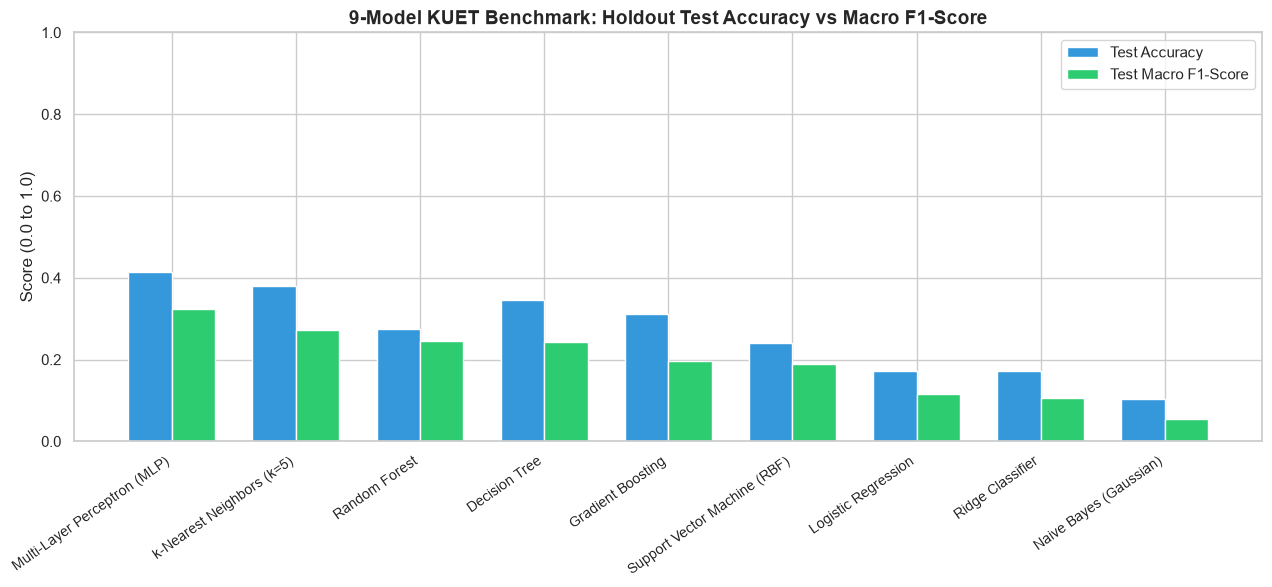

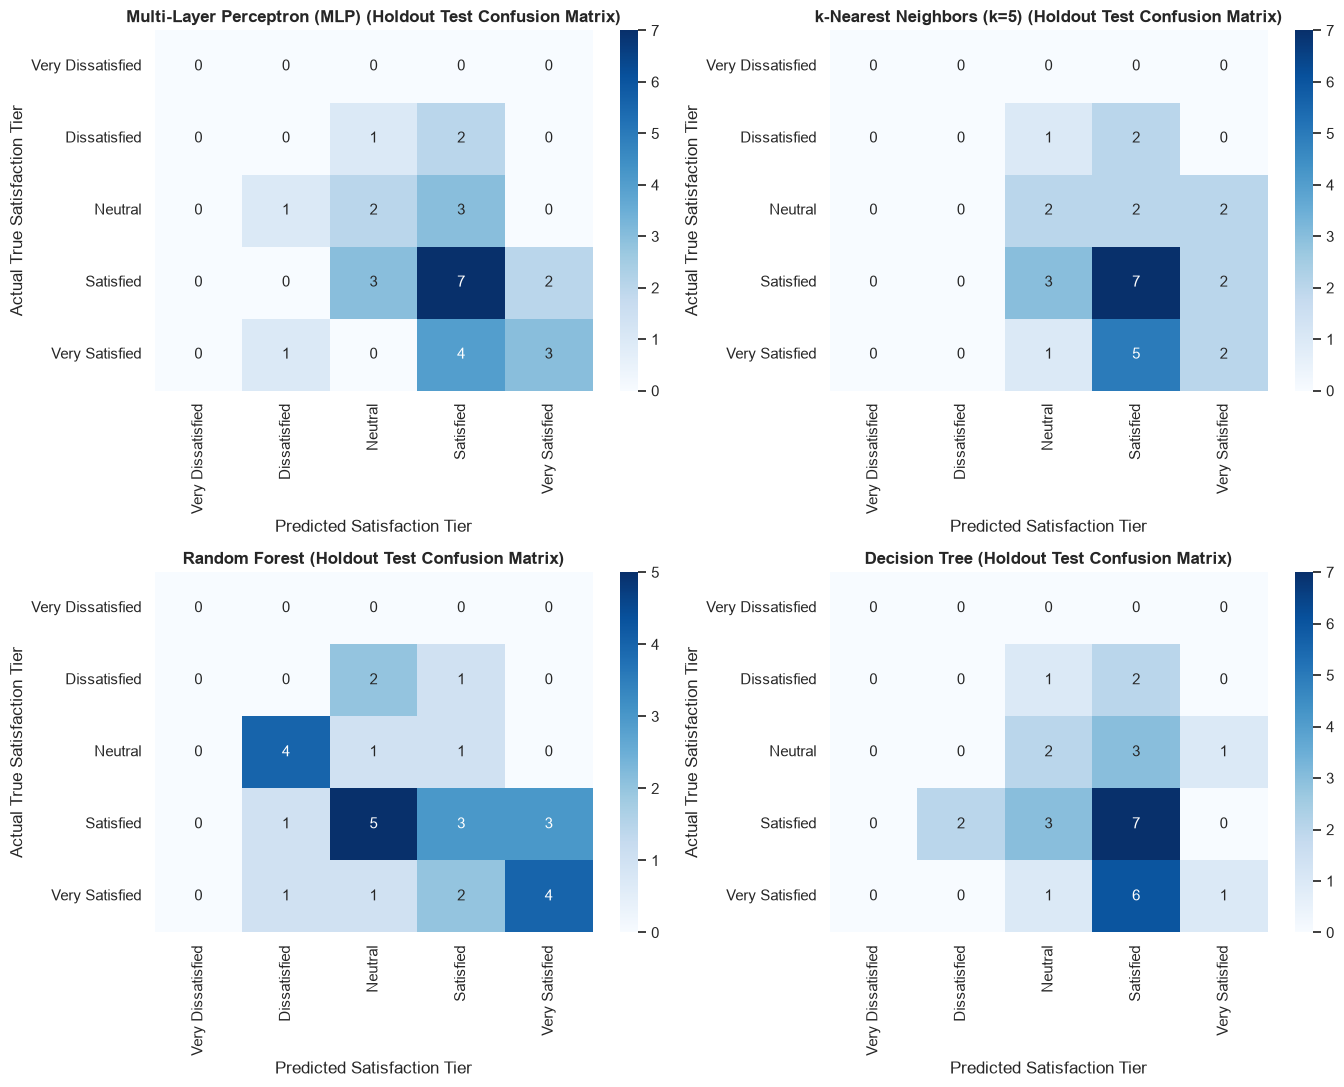

In [18]:
# 1. Bar Plot Comparison of Test Accuracy and Macro F1
plot_df = benchmark_df.copy()
plot_df['Test Accuracy'] = plot_df['_raw_test_acc']
plot_df['Test Macro F1'] = plot_df['_raw_test_f1']

fig, ax = plt.subplots(figsize=(13, 6))
x_idx = np.arange(len(plot_df))
bar_width = 0.35

rects1 = ax.bar(x_idx - bar_width/2, plot_df['Test Accuracy'], bar_width, label='Test Accuracy', color='#3498db')
rects2 = ax.bar(x_idx + bar_width/2, plot_df['Test Macro F1'], bar_width, label='Test Macro F1-Score', color='#2ecc71')

ax.set_ylabel('Score (0.0 to 1.0)', fontsize=12)
ax.set_title('9-Model KUET Benchmark: Holdout Test Accuracy vs Macro F1-Score', fontsize=14, fontweight='bold')
ax.set_xticks(x_idx)
ax.set_xticklabels(plot_df['Model Name'], rotation=35, ha='right', fontsize=10)
ax.set_ylim(0, 1.0)
ax.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

# 2. Confusion Matrices for Top 4 Models
top_4_models = [benchmark_df.iloc[0]['Model Name'], benchmark_df.iloc[1]['Model Name'],
                benchmark_df.iloc[2]['Model Name'], benchmark_df.iloc[3]['Model Name']]
labels_order = [l for l in ['Very Dissatisfied', 'Dissatisfied', 'Neutral', 'Satisfied', 'Very Satisfied'] if l in df['Target_5Class'].unique()]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for idx, m_name in enumerate(top_4_models):
    pipe = trained_models[m_name]
    preds = pipe.predict(X_test)
    
    cm = confusion_matrix(y_test, preds, labels=labels_order)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_order, yticklabels=labels_order, ax=axes[idx])
    axes[idx].set_title(f'{m_name} (Holdout Test Confusion Matrix)', fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('Predicted Satisfaction Tier')
    axes[idx].set_ylabel('Actual True Satisfaction Tier')

plt.tight_layout()
plt.show()

## 16. Multi-Class One-vs-Rest (OvR) ROC Curves & Macro AUC Diagnostics
We compute receiver operating characteristic curves and macro-averaged AUC diagnostics for probability-enabled models.

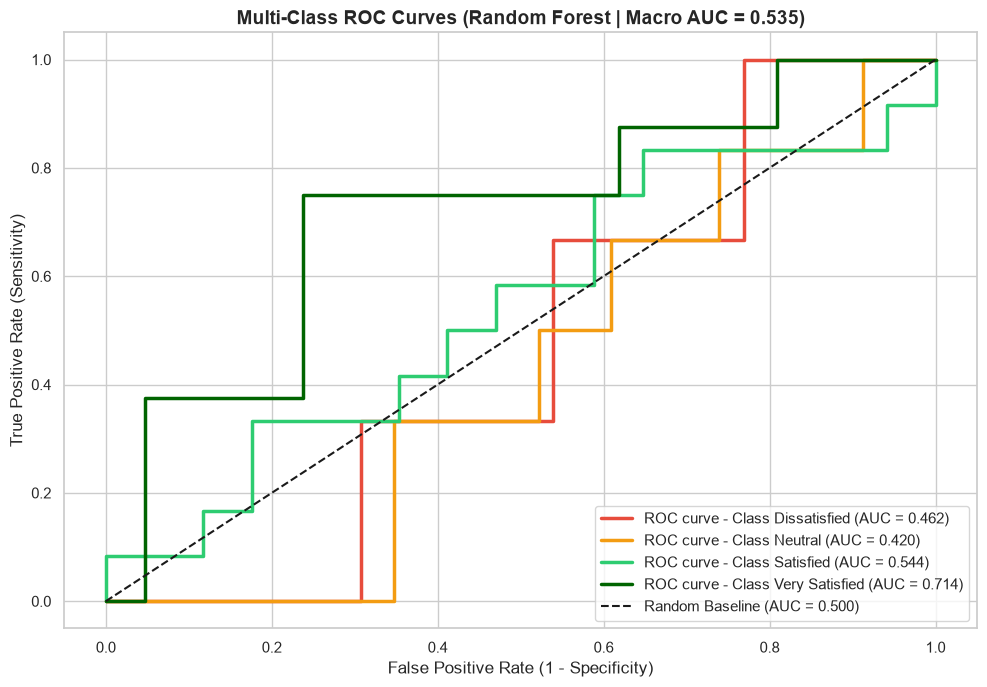

In [19]:
# Multi-Class OvR ROC for Active Classes in KUET Holdout Test Set
active_roc_classes = [c for c in ['Very Dissatisfied', 'Dissatisfied', 'Neutral', 'Satisfied', 'Very Satisfied'] if (y_test == c).sum() > 0]
y_test_bin = label_binarize(y_test, classes=active_roc_classes)
n_classes = len(active_roc_classes)

best_model_name = 'Random Forest'
best_pipe = trained_models[best_model_name]

if hasattr(best_pipe, "predict_proba"):
    y_score_raw = best_pipe.predict_proba(X_test)
    model_classes = list(best_pipe.named_steps['classifier'].classes_)
    class_indices = [model_classes.index(label) for label in active_roc_classes if label in model_classes]
    y_score = y_score_raw[:, class_indices]
    
    fpr, tpr, roc_auc = dict(), dict(), dict()
    palette_dict = {'Very Dissatisfied': '#8b0000', 'Dissatisfied': '#e74c3c', 'Neutral': '#f39c12', 'Satisfied': '#2ecc71', 'Very Satisfied': '#006400'}
    
    plt.figure(figsize=(10, 7))
    for i, cls_name in enumerate(active_roc_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], color=palette_dict.get(cls_name, '#3498db'), lw=2.5,
                 label=f'ROC curve - Class {cls_name} (AUC = {roc_auc[i]:.3f})')
    
    # Compute Macro Average AUC
    macro_auc = roc_auc_score(y_test_bin, y_score, average='macro', multi_class='ovr')
    plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Baseline (AUC = 0.500)')
    plt.title(f'Multi-Class ROC Curves ({best_model_name} | Macro AUC = {macro_auc:.3f})', fontsize=14, fontweight='bold')
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.legend(loc='lower right', fontsize=11)
    plt.tight_layout()
    plt.show()

## 17. Feature Importance Diagnostics (Random Forest Gini Importance)
We extract Gini feature importances to identify the most influential predictors of graduate career satisfaction in the KUET cohort.

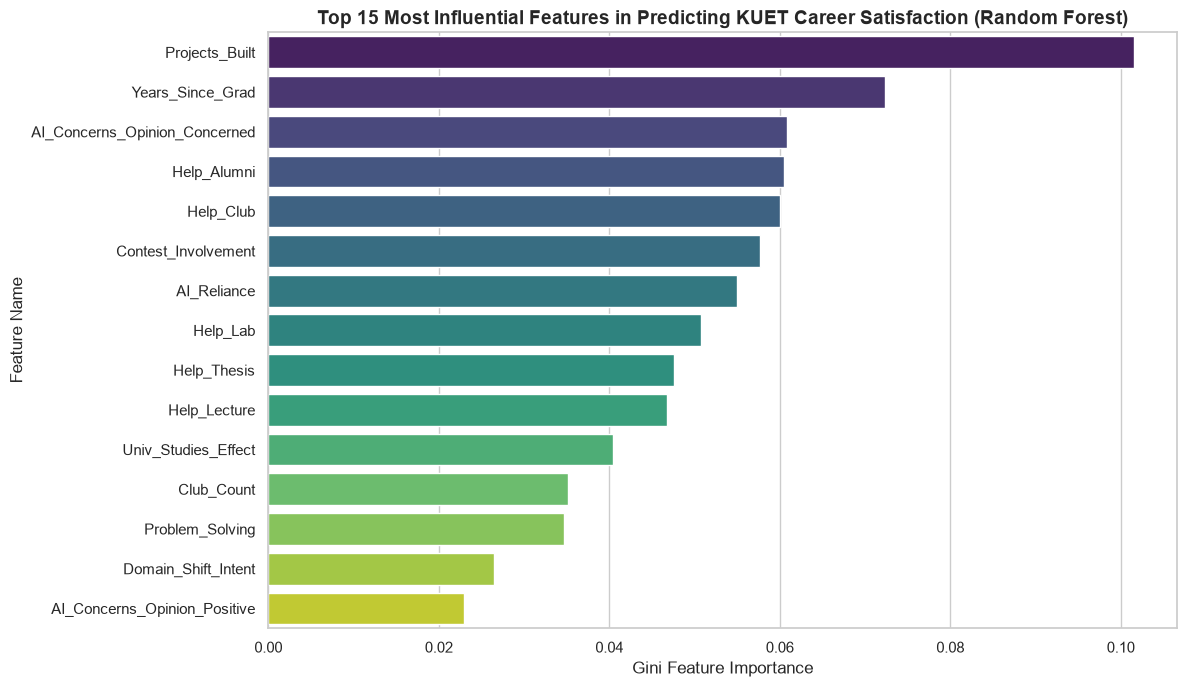

--- Top 10 Most Influential Features Table (KUET Cohort) ---


,Feature Name,Importance Score
0,Projects_Built,0.101516
1,Years_Since_Grad,0.072311
2,AI_Concerns_Opinion_Concerned,0.060839
3,Help_Alumni,0.060505
4,Help_Club,0.059989
5,Contest_Involvement,0.057615
6,AI_Reliance,0.054961
7,Help_Lab,0.050733
8,Help_Thesis,0.047626
9,Help_Lecture,0.046737


In [20]:
rf_model = trained_models['Random Forest'].named_steps['classifier']
ohe_feature_names = trained_models['Random Forest'].named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()
all_feature_names = numeric_cols + ohe_feature_names

importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature Name': all_feature_names,
    'Importance Score': importances
}).sort_values(by='Importance Score', ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 7))
sns.barplot(data=feat_imp_df.head(15), x='Importance Score', y='Feature Name', palette='viridis')
plt.title('Top 15 Most Influential Features in Predicting KUET Career Satisfaction (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Gini Feature Importance', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.tight_layout()
plt.show()

print("--- Top 10 Most Influential Features Table (KUET Cohort) ---")
display(feat_imp_df.head(10))

## 18. Export Clean KUET Datasets for WEKA GUI Replication
We export the final clean KUET dataset to `.csv` and `.arff` formats for WEKA modeling and benchmarking.

In [21]:
export_df = X.copy()
export_df['Career_Satisfaction'] = y.values

# Save clean CSV
csv_filename = 'career_satisfaction_5class_kuet_processed.csv'
export_df.to_csv(csv_filename, index=False)
print(f"Saved clean preprocessed KUET CSV: {csv_filename} ({len(export_df)} rows, {len(export_df.columns)} columns)")

# Generate WEKA ARFF File with exact nominal quoting
def export_arff(df_in, target_col_name, filename):
    nominal_cols = ['Professional_Status', 'Current_Domain', 'AI_Concerns_Opinion', target_col_name]
    lines = []
    lines.append("@relation career_satisfaction_5class_kuet_classification\n")
    
    for col in df_in.columns:
        if col == target_col_name:
            lines.append(f"@attribute {col} {{'Very Dissatisfied', Dissatisfied, Neutral, Satisfied, 'Very Satisfied'}}")
        elif col in nominal_cols or df_in[col].dtype == 'object':
            uvals = sorted(list(df_in[col].dropna().unique()))
            formatted_vals = []
            for v in uvals:
                cleaned_v = str(v).replace("'", "").replace('"', '').strip()
                if any(char in cleaned_v for char in [' ', '/', '&', '-', '(', ')']):
                    formatted_vals.append(f"'{cleaned_v}'")
                else:
                    formatted_vals.append(cleaned_v)
            vals_str = "{" + ", ".join(formatted_vals) + "}"
            lines.append(f"@attribute {col} {vals_str}")
        else:
            lines.append(f"@attribute {col} numeric")
            
    lines.append("\n@data")
    for _, row in df_in.iterrows():
        row_strs = []
        for col in df_in.columns:
            val = row[col]
            if col in nominal_cols or df_in[col].dtype == 'object':
                cleaned_val = str(val).replace("'", "").replace('"', '').strip()
                if any(char in cleaned_val for char in [' ', '/', '&', '-', '(', ')']):
                    row_strs.append(f"'{cleaned_val}'")
                else:
                    row_strs.append(cleaned_val)
            else:
                if pd.isna(val):
                    row_strs.append("?")
                elif isinstance(val, (int, float, np.integer, np.floating)) and float(val).is_integer():
                    row_strs.append(str(int(val)))
                else:
                    row_strs.append(f"{float(val):.4f}")
        lines.append(",".join(row_strs))
        
    with open(filename, 'w', encoding='utf-8') as f:
        f.write("\n".join(lines) + "\n")
    print(f"Saved WEKA ARFF file: {filename}")

arff_filename = 'career_satisfaction_5class_kuet_weka.arff'
export_arff(export_df, 'Career_Satisfaction', arff_filename)

Saved clean preprocessed KUET CSV: career_satisfaction_5class_kuet_processed.csv (143 rows, 21 columns)
Saved WEKA ARFF file: career_satisfaction_5class_kuet_weka.arff
